##MULTIMODAL FUSION — PEDIATRIC PNEUMONIA CLASSIFICATION
###Late Fusion (Weighted Averaging) + Gated Fusion
###Full Evaluation: Accuracy, Precision, Recall, F1, ROC-AUC


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['PYTHONHASHSEED'] = '42'

import warnings
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split

import json
import pickle

import random
warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

In [ ]:
XRAY_MODEL_PATH   = '/content/drive/MyDrive/IIT/FYP/Implementation/models/ResNet50_best.keras'
COUGH_MODEL_PATH  = '/content/drive/MyDrive/IIT/FYP/Implementation/models/cough_sound/mfcc_cnn_bilstm_best2.keras'
FEATURES_DIR      = '/content/drive/MyDrive/IIT/FYP/Implementation/data/Cough_Sound/mfcc_features'
SPLIT_TEST_DIR    = '/content/drive/MyDrive/IIT/FYP/Implementation/data/Chest_Xray/chest_xray_split/test'
SPLIT_VAL_DIR     = '/content/drive/MyDrive/IIT/FYP/Implementation/data/Chest_Xray/chest_xray_split/val'

In [ ]:
IMG_SIZE         = (224, 224)
XRAY_THRESHOLD   = 0.6677     # Youden's J from X-ray val
COUGH_THRESHOLD  = 0.4295     # Youden's J from CNN-BiLSTM val
N_SEEDS          = 20
CLASS_NAMES      = ['Normal', 'Pneumonia']

LOAD MODELS

In [ ]:
print("Loading models...")
xray_model  = keras.models.load_model(XRAY_MODEL_PATH)
cough_model = keras.models.load_model(COUGH_MODEL_PATH)

# Freeze both models — used only as probability generators
xray_model.trainable  = False
cough_model.trainable = False

print("Models loaded and frozen.")

Loading models...
Models loaded and frozen.


PREPARE DATA & EXTRACT UNIMODAL PREDICTIONS

In [ ]:
# X-ray generators
def make_xray_gen(folder):
    """ImageDataGenerator with ResNet50 preprocessing. Shuffle disabled."""
    return ImageDataGenerator(preprocessing_function=resnet_preprocess) \
           .flow_from_directory(folder, target_size=IMG_SIZE,
                                batch_size=32, class_mode='binary',
                                shuffle=False)

val_gen_xray  = make_xray_gen(SPLIT_VAL_DIR)
test_gen_xray = make_xray_gen(SPLIT_TEST_DIR)

Found 524 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
# Cough MFCC arrays
X_val_cough  = np.load(os.path.join(FEATURES_DIR, 'X_val_mfcc.npy'))
y_val_cough  = np.load(os.path.join(FEATURES_DIR, 'y_val.npy'))
X_test_cough = np.load(os.path.join(FEATURES_DIR, 'X_test_mfcc.npy'))
y_test_cough = np.load(os.path.join(FEATURES_DIR, 'y_test.npy'))

# Add channel dimension to match CNN-BiLSTM input: (samples, 100, 60, 1)
X_val_cough  = X_val_cough[..., np.newaxis]
X_test_cough = X_test_cough[..., np.newaxis]

In [ ]:
# Extract probability predictions
print("Extracting unimodal predictions...")

p_xray_val   = xray_model.predict(val_gen_xray,   verbose=0).flatten()
p_xray_test  = xray_model.predict(test_gen_xray,  verbose=0).flatten()
y_xray_val   = val_gen_xray.classes
y_xray_test  = test_gen_xray.classes

p_cough_val  = cough_model.predict(X_val_cough,   verbose=0).flatten()
p_cough_test = cough_model.predict(X_test_cough,  verbose=0).flatten()
y_cough_val  = y_val_cough
y_cough_test = y_test_cough

print(f"\nX-ray  val  : p={p_xray_val.shape},  y={y_xray_val.shape}")
print(f"X-ray  test : p={p_xray_test.shape},  y={y_xray_test.shape}")
print(f"Cough  val  : p={p_cough_val.shape},  y={y_cough_val.shape}")
print(f"Cough  test : p={p_cough_test.shape},  y={y_cough_test.shape}")
print(f"\nX-ray val  Pneumonia % : {y_xray_val.mean():.3f}")
print(f"Cough val  Pneumonia % : {y_cough_val.mean():.3f}")

Extracting unimodal predictions...

X-ray  val  : p=(524,),  y=(524,)
X-ray  test : p=(624,),  y=(624,)
Cough  val  : p=(83,),  y=(83,)
Cough  test : p=(77,),  y=(77,)

X-ray val  Pneumonia % : 0.742
Cough val  Pneumonia % : 0.422


SHARED UTILITIES

In [ ]:
# pseudo pairing by label
def create_fusion_pairs(p_xray, y_xray, p_cough, y_cough, seed=42):
    """
    Pseudo pairing by class label.

    For each X-ray sample, randomly select one cough sample
    from the same class. Cough samples can be reused, so the
    final paired set size matches the X-ray set size.

    Returns paired probability arrays and a shared label array.
    """
    rng = np.random.default_rng(seed)
    px_out, pc_out, y_out = [], [], []

    for label in [0, 1]:
        idx_x = np.where(y_xray == label)[0]
        idx_c = np.where(y_cough == label)[0]

        if len(idx_c) == 0:
            raise ValueError(f"No cough samples found for class {label}")

        # keep all X-ray samples in this class
        px_label = p_xray[idx_x]

        # randomly assign same-class cough samples with replacement
        chosen_cough_idx = rng.choice(idx_c, size=len(idx_x), replace=True)
        pc_label = p_cough[chosen_cough_idx]

        y_label = np.full(len(idx_x), label)

        px_out.append(px_label)
        pc_out.append(pc_label)
        y_out.append(y_label)

    return (
        np.concatenate(px_out),
        np.concatenate(pc_out),
        np.concatenate(y_out)
    )

In [ ]:
px_val_pair, pc_val_pair, y_val_pair = create_fusion_pairs(
    p_xray_val, y_xray_val, p_cough_val, y_cough_val, seed=42
)

px_test_pair, pc_test_pair, y_test_pair = create_fusion_pairs(
    p_xray_test, y_xray_test, p_cough_test, y_cough_test, seed=42
)

print("Paired val  :", px_val_pair.shape, pc_val_pair.shape, y_val_pair.shape)
print("Paired test :", px_test_pair.shape, pc_test_pair.shape, y_test_pair.shape)

Paired val  : (524,) (524,) (524,)
Paired test : (624,) (624,) (624,)


In [ ]:
def find_optimal_threshold_youden(p_fused, y_true):
    """
    Finds the classification threshold that maximises Youden's J statistic:
    J = TPR - FPR (sensitivity + specificity - 1).
    """
    fpr, tpr, thresholds = roc_curve(y_true, p_fused)
    best_idx = np.argmax(tpr - fpr)
    return float(thresholds[best_idx])

In [ ]:
def compute_all_metrics(y_true, y_pred, p_score):
    """Returns dict of all 5 classification metrics for one seed."""
    return {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall'   : recall_score(y_true, y_pred, zero_division=0),
        'f1'       : f1_score(y_true, y_pred, zero_division=0),
        'auc'      : roc_auc_score(y_true, p_score),
    }

In [ ]:
def aggregate_metrics(metric_dict):
    """Returns mean and std for each metric across all seeds."""
    return {k: (np.mean(v), np.std(v)) for k, v in metric_dict.items()}


def empty_metric_store():
    """Returns fresh empty lists for all metrics."""
    return {'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'auc': []}

In [ ]:
METRIC_LABELS = [
    ('accuracy',  'Accuracy'),
    ('precision', 'Precision'),
    ('recall',    'Recall'),
    ('f1',        'F1-Score'),
    ('auc',       'ROC-AUC'),
]

###APPROACH 1: LATE FUSION (WEIGHTED AVERAGING)

In [ ]:
# Weight sweep on Val — averaged over N seeds
weights = np.arange(0.0, 1.05, 0.05)

# acc_matrix shape: (N_SEEDS, len(weights))
acc_matrix = np.zeros((N_SEEDS, len(weights)))

for s in range(N_SEEDS):
    px_v, pc_v, y_v = create_fusion_pairs(
        p_xray_val, y_xray_val,
        p_cough_val, y_cough_val, seed=s
    )
    for i, w in enumerate(weights):
        p_fused        = w * px_v + (1 - w) * pc_v
        acc_matrix[s, i] = accuracy_score(y_v, (p_fused >= 0.5).astype(int))

mean_val_acc = acc_matrix.mean(axis=0)
std_val_acc  = acc_matrix.std(axis=0)

best_idx = np.argmax(mean_val_acc)
best_w   = weights[best_idx]

print(f"Best w_xray : {best_w:.2f}  |  w_cough : {1 - best_w:.2f}")
print(f"Val Accuracy (mean ± std): {mean_val_acc[best_idx]:.4f} ± {std_val_acc[best_idx]:.4f}")

Best w_xray : 0.65  |  w_cough : 0.35
Val Accuracy (mean ± std): 0.9743 ± 0.0037


In [ ]:
# Find optimal threshold via Youden's J on val
late_thresh_list = []
for s in range(N_SEEDS):
    px_v, pc_v, y_v = create_fusion_pairs(
        p_xray_val, y_xray_val, p_cough_val, y_cough_val, seed=s)
    p_fused_v = best_w * px_v + (1 - best_w) * pc_v
    late_thresh_list.append(find_optimal_threshold_youden(p_fused_v, y_v))

LATE_THRESHOLD = np.mean(late_thresh_list)
print(f"Optimal Threshold (mean Youden's J across seeds): {LATE_THRESHOLD:.4f}")

Optimal Threshold (mean Youden's J across seeds): 0.5601


In [ ]:
# Per-seed storage for classification report
late_per_seed_report = {
    'normal_prec': [], 'normal_rec': [], 'normal_f1': [],
    'pneumonia_prec': [], 'pneumonia_rec': [], 'pneumonia_f1': [],
    'normal_support': [], 'pneumonia_support': []
}

In [ ]:
# Evaluate on test set across all seeds
late_metrics  = empty_metric_store()
xray_metrics  = empty_metric_store()
cough_metrics = empty_metric_store()

late_all_y_true, late_all_y_pred   = [], []
late_all_p_fused                   = []
late_fpr_list,   late_tpr_list     = [], []
late_last                          = {}

for s in range(N_SEEDS):
    px_t, pc_t, y_t = create_fusion_pairs(
        p_xray_test, y_xray_test, p_cough_test, y_cough_test, seed=s)

    p_fused = best_w * px_t + (1 - best_w) * pc_t
    y_pred  = (p_fused >= LATE_THRESHOLD).astype(int)

    # Overall metrics
    m = compute_all_metrics(y_t, y_pred, p_fused)
    for k in late_metrics:
        late_metrics[k].append(m[k])

    # Unimodal on same paired subset
    mx = compute_all_metrics(y_t, (px_t >= XRAY_THRESHOLD).astype(int), px_t)
    mc = compute_all_metrics(y_t, (pc_t >= COUGH_THRESHOLD).astype(int), pc_t)
    for k in xray_metrics:
        xray_metrics[k].append(mx[k])
        cough_metrics[k].append(mc[k])

    # Per-class metrics for per-seed classification report
    from sklearn.metrics import precision_recall_fscore_support
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_t, y_pred, labels=[0, 1], zero_division=0)
    late_per_seed_report['normal_prec'].append(prec[0])
    late_per_seed_report['normal_rec'].append(rec[0])
    late_per_seed_report['normal_f1'].append(f1[0])
    late_per_seed_report['pneumonia_prec'].append(prec[1])
    late_per_seed_report['pneumonia_rec'].append(rec[1])
    late_per_seed_report['pneumonia_f1'].append(f1[1])
    late_per_seed_report['normal_support'].append(sup[0])
    late_per_seed_report['pneumonia_support'].append(sup[1])

    late_all_y_true.append(y_t)
    late_all_y_pred.append(y_pred)
    late_all_p_fused.append(p_fused)
    fpr, tpr, _ = roc_curve(y_t, p_fused)
    late_fpr_list.append(fpr)
    late_tpr_list.append(tpr)

    if s == N_SEEDS - 1:
        late_last = {'y_true': y_t, 'y_pred': y_pred,
                     'p_fused': p_fused, 'thresh': LATE_THRESHOLD}

print("Late Fusion evaluation complete.")

Late Fusion evaluation complete.


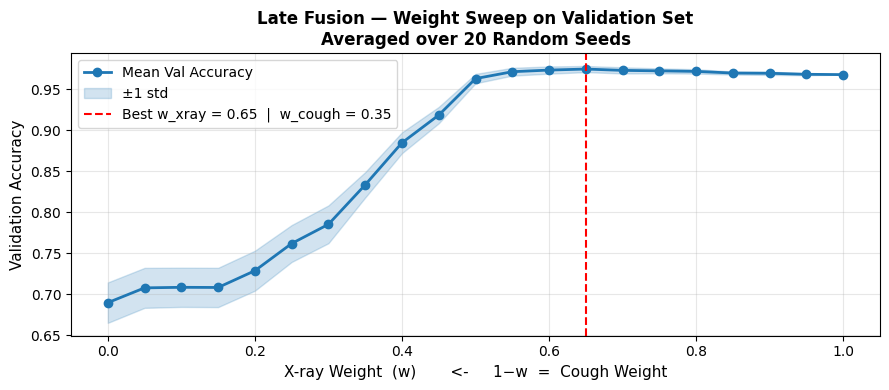

In [ ]:
# Weight Sweep
plt.figure(figsize=(9, 4))
plt.plot(weights, mean_val_acc, marker='o', linewidth=2,
         color='#1f77b4', label='Mean Val Accuracy')
plt.fill_between(weights,
                 mean_val_acc - std_val_acc,
                 mean_val_acc + std_val_acc,
                 alpha=0.2, color='#1f77b4', label='±1 std')
plt.axvline(best_w, color='red', linestyle='--',
            label=f'Best w_xray = {best_w:.2f}  |  w_cough = {1 - best_w:.2f}')
plt.xlabel("X-ray Weight  (w)       <-     1−w  =  Cough Weight", fontsize=11)
plt.ylabel("Validation Accuracy", fontsize=11)
plt.title("Late Fusion — Weight Sweep on Validation Set\n"
          f"Averaged over {N_SEEDS} Random Seeds", fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###APPROACH 2: GATED FUSION

In [ ]:
# Feature Builder
def build_gate_features(p_xray, p_cough):
    """
    7 features per sample.
    Drops raw entropy (redundant with confidence).
    Adds agreement, directional diff, relative confidence.
    """
    conf_x   = np.abs(p_xray  - 0.5)           # x-ray confidence
    conf_c   = np.abs(p_cough - 0.5)           # cough confidence
    agree    = 1.0 - np.abs(p_xray - p_cough)  # agreement signal
    diff     = p_xray - p_cough                 # directional difference
    rel_conf = conf_x - conf_c                  # relative confidence

    return np.stack(
        [p_xray, p_cough, conf_x, conf_c, agree, diff, rel_conf],
        axis=1
    ).astype(np.float32)

In [ ]:
# Gate Network
def build_gate_model(input_dim=7):
    """
    Small MLP gate: 1 hidden layer (8 units) + Dropout(0.3) + L2=1e-2.
    Architecture chosen for 524 paired training samples:
    """
    inp = keras.Input(shape=(input_dim,))
    x   = layers.Dense(8, activation='relu', kernel_regularizer=regularizers.l2(1e-2))(inp)
    x   = layers.Dropout(0.3)(x)
    g   = layers.Dense(1, activation='sigmoid', kernel_regularizer=regularizers.l2(1e-2))(x)
    return keras.Model(inp, g)

In [ ]:
def split_paired_val_set(px, pc, y, test_size=0.2, seed=0):
    """
    Split paired validation set into:
    - gate training subset
    - threshold tuning subset

    Stratified by class labels.
    """
    idx = np.arange(len(y))

    idx_train, idx_thr = train_test_split(
        idx,
        test_size=test_size,
        random_state=seed,
        stratify=y
    )

    return (
        px[idx_train], pc[idx_train], y[idx_train],   # gate-train
        px[idx_thr],   pc[idx_thr],   y[idx_thr]      # threshold-tune
    )

In [ ]:
# Training function
def train_gate_full(px, pc, y, seed=0, epochs=50, lr=1e-3):
    """
    Trains on ALL paired validation samples
    """
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)

    X  = build_gate_features(px, pc)
    px = px.astype(np.float32)
    pc = pc.astype(np.float32)
    y  = y.astype(np.float32)

    gate      = build_gate_model(input_dim=X.shape[1])
    optimizer = keras.optimizers.Adam(lr)

    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            g       = gate(X, training=True)[:, 0]
            p_fused = tf.clip_by_value(g * px + (1.0 - g) * pc, 1e-7, 1 - 1e-7)
            loss    = tf.reduce_mean(
                          keras.losses.binary_crossentropy(y, p_fused))
        grads = tape.gradient(loss, gate.trainable_variables)
        optimizer.apply_gradients(zip(grads, gate.trainable_variables))

    return gate

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

In [ ]:
# Multi-seed training and evaluation
gated_metrics = empty_metric_store()
gated_all_y_true, gated_all_y_pred = [], []
gated_all_p_fused                  = []
gated_fpr_list, gated_tpr_list     = [], []
gated_thresh_list, gate_mean_g     = [], []
gated_last                         = {}

# Per-seed storage for classification report
gated_per_seed_report = {
    'normal_prec': [], 'normal_rec': [], 'normal_f1': [],
    'pneumonia_prec': [], 'pneumonia_rec': [], 'pneumonia_f1': [],
    'normal_support': [], 'pneumonia_support': []
}

print("Training Gated Fusion across {N_SEEDS} seeds...\n")

for seed in range(N_SEEDS):
    # Pair val (gate training) and test (evaluation)
    px_val_p, pc_val_p, y_val_p   = create_fusion_pairs(
        p_xray_val,  y_xray_val,  p_cough_val,  y_cough_val,  seed=seed)
    px_test_p, pc_test_p, y_test_p = create_fusion_pairs(
        p_xray_test, y_xray_test, p_cough_test, y_cough_test, seed=seed)

    # Train gate on all paired val samples
    gate = train_gate_full(px_val_p, pc_val_p, y_val_p, seed=seed)

    # Find per-seed optimal threshold using Youden's J on val
    X_val_f     = build_gate_features(px_val_p, pc_val_p)
    g_val       = gate(X_val_f, training=False).numpy()[:, 0]
    p_fused_val = g_val * px_val_p + (1 - g_val) * pc_val_p
    thresh      = find_optimal_threshold_youden(p_fused_val, y_val_p)
    gated_thresh_list.append(thresh)

    # Inference on test
    X_test_f      = build_gate_features(px_test_p, pc_test_p)
    g_test        = gate(X_test_f, training=False).numpy()[:, 0]
    p_fused_test  = g_test * px_test_p + (1 - g_test) * pc_test_p
    y_pred_gated  = (p_fused_test >= thresh).astype(int)

    gate_mean_g.append(g_test.mean())

    # Overall metrics
    m = compute_all_metrics(y_test_p, y_pred_gated, p_fused_test)
    for k in gated_metrics:
        gated_metrics[k].append(m[k])

    # Per-class metrics for per-seed classification report
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_test_p, y_pred_gated, labels=[0, 1], zero_division=0)
    gated_per_seed_report['normal_prec'].append(prec[0])
    gated_per_seed_report['normal_rec'].append(rec[0])
    gated_per_seed_report['normal_f1'].append(f1[0])
    gated_per_seed_report['pneumonia_prec'].append(prec[1])
    gated_per_seed_report['pneumonia_rec'].append(rec[1])
    gated_per_seed_report['pneumonia_f1'].append(f1[1])
    gated_per_seed_report['normal_support'].append(sup[0])
    gated_per_seed_report['pneumonia_support'].append(sup[1])

    # ROC data
    gated_all_y_true.append(y_test_p)
    gated_all_y_pred.append(y_pred_gated)
    gated_all_p_fused.append(p_fused_test)
    fpr, tpr, _ = roc_curve(y_test_p, p_fused_test)
    gated_fpr_list.append(fpr)
    gated_tpr_list.append(tpr)

    if seed == N_SEEDS - 1:
        gated_last = {'y_true': y_test_p, 'y_pred': y_pred_gated,
                      'p_fused': p_fused_test, 'thresh': thresh}

print(f"Done.")
print(f"Mean gate weight g     = {np.mean(gate_mean_g):.4f}  "
      f"(1.0 = fully trusts X-ray, 0.0 = fully trusts Cough)")
print(f"Mean Youden threshold  = {np.mean(gated_thresh_list):.4f} ± "
      f"{np.std(gated_thresh_list):.4f}")

Training Gated Fusion across {N_SEEDS} seeds...

Done.
Mean gate weight g     = 0.5823  (1.0 = fully trusts X-ray, 0.0 = fully trusts Cough)
Mean Youden threshold  = 0.5285 ± 0.0798


In [ ]:
SAVE_DIR = '/content/drive/MyDrive/IIT/FYP/Implementation/models/fusion'
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
# SAVE FINAL GATE MODEL
FINAL_GATE_SEED = 0

# Retrain final gate deterministically on seed=0
px_val_final, pc_val_final, y_val_final = create_fusion_pairs(
    p_xray_val, y_xray_val,
    p_cough_val, y_cough_val,
    seed=FINAL_GATE_SEED)

final_gate = train_gate_full(
    px_val_final, pc_val_final, y_val_final,
    seed=FINAL_GATE_SEED, epochs=50)

# Save gate model
gate_save_path = os.path.join(SAVE_DIR, 'gated_fusion_gate_Pseudo_50.keras')
final_gate.save(gate_save_path)
print(f"\nSaved gate model : {gate_save_path}")


Saved gate model : /content/drive/MyDrive/IIT/FYP/Implementation/models/fusion/gated_fusion_gate_Pseudo_50.keras


In [ ]:
def print_per_seed_report(report_dict, acc_list, title, threshold_info=""):
    """
    Prints a classification_report-style table using
    per-seed averaged precision, recall, F1 and support.
    All values shown as mean ± std across N_SEEDS.
    """
    n_prec = np.array(report_dict['normal_prec'])
    n_rec  = np.array(report_dict['normal_rec'])
    n_f1   = np.array(report_dict['normal_f1'])
    p_prec = np.array(report_dict['pneumonia_prec'])
    p_rec  = np.array(report_dict['pneumonia_rec'])
    p_f1   = np.array(report_dict['pneumonia_f1'])
    n_sup  = np.array(report_dict['normal_support'])
    p_sup  = np.array(report_dict['pneumonia_support'])

    total_sup   = n_sup + p_sup
    macro_f1    = (n_f1   + p_f1)   / 2
    macro_prec  = (n_prec + p_prec) / 2
    macro_rec   = (n_rec  + p_rec)  / 2
    weighted_f1 = (n_f1   * n_sup + p_f1   * p_sup) / total_sup
    w_prec      = (n_prec * n_sup + p_prec * p_sup) / total_sup
    w_rec       = (n_rec  * n_sup + p_rec  * p_sup) / total_sup
    acc         = np.array(acc_list)

    # Column widths
    W_CLASS = 16    # class name column
    W_VAL   = 18    # each metric column  (mean±std fits in 13 chars, padded)
    W_SUP   = 10    # support column

    def fmt(mean, std):
        """Format as mean±std, fixed width."""
        return f"{mean:.4f}±{std:.4f}"

    def row(name, prec_m, prec_s, rec_m, rec_s, f1_m, f1_s, sup_m, sup_s=None):
        sup_str = f"{sup_m:.1f}" if sup_s is None else f"{sup_m:.1f}"
        return (f"{name:>{W_CLASS}}  "
                f"{fmt(prec_m, prec_s):>{W_VAL}}  "
                f"{fmt(rec_m,  rec_s):>{W_VAL}}  "
                f"{fmt(f1_m,   f1_s):>{W_VAL}}  "
                f"{sup_str:>{W_SUP}}")

    def row_acc(acc_m, acc_s, sup_m):
        """Accuracy row — blank precision and recall columns."""
        blank = " " * W_VAL
        return (f"{'accuracy':>{W_CLASS}}  "
                f"{blank}  "
                f"{blank}  "
                f"{fmt(acc_m, acc_s):>{W_VAL}}  "
                f"{sup_m:>{W_SUP}.1f}")

    SEP = "=" * 96
    sep = "-" * 96

    print("\n" + SEP)
    print(f"  CLASSIFICATION REPORT — {title}")
    print(f"  Per-Seed Average over {N_SEEDS} Random Seeds  {threshold_info}")
    print(SEP)
    print(f"{'':>{W_CLASS}}  "
          f"{'precision':>{W_VAL}}  "
          f"{'recall':>{W_VAL}}  "
          f"{'f1-score':>{W_VAL}}  "
          f"{'support':>{W_SUP}}")
    print(sep)
    print(row("Normal",
              np.mean(n_prec), np.std(n_prec),
              np.mean(n_rec),  np.std(n_rec),
              np.mean(n_f1),   np.std(n_f1),
              np.mean(n_sup)))
    print(row("Pneumonia",
              np.mean(p_prec), np.std(p_prec),
              np.mean(p_rec),  np.std(p_rec),
              np.mean(p_f1),   np.std(p_f1),
              np.mean(p_sup)))
    print(sep)
    print(row_acc(np.mean(acc), np.std(acc), np.mean(total_sup)))
    print(row("macro avg",
              np.mean(macro_prec), np.std(macro_prec),
              np.mean(macro_rec),  np.std(macro_rec),
              np.mean(macro_f1),   np.std(macro_f1),
              np.mean(total_sup)))
    print(row("weighted avg",
              np.mean(w_prec), np.std(w_prec),
              np.mean(w_rec),  np.std(w_rec),
              np.mean(weighted_f1), np.std(weighted_f1),
              np.mean(total_sup)))
    print(SEP)


###FULL EVALUATION — METRIC TABLES

In [ ]:
print("\n" + "=" * 78)
print("  FULL EVALUATION ON HELD-OUT TEST SET")
print("  All metrics averaged over 20 random seeds (mean ± std)")
print("=" * 78)

xray_agg  = aggregate_metrics(xray_metrics)
cough_agg = aggregate_metrics(cough_metrics)
late_agg  = aggregate_metrics(late_metrics)
gated_agg = aggregate_metrics(gated_metrics)


def print_metric_table(fusion_agg, fusion_label):
    short = fusion_label.split()[0]
    print(f"\n{'─'*78}")
    print(f"  {fusion_label}")
    print(f"{'─'*78}")
    print(f"{'Metric':<14} {'X-ray (ResNet50)':^22} {'Cough (CNN-BiLSTM)':^22} {short+' Fusion':^18}")
    print(f"{'─'*78}")
    for key, label in METRIC_LABELS:
        xm, xs = xray_agg[key]
        cm, cs = cough_agg[key]
        fm, fs = fusion_agg[key]
        print(f"{label:<14}  {xm:.4f} ± {xs:.4f}     {cm:.4f} ± {cs:.4f}     {fm:.4f} ± {fs:.4f}")
    print(f"{'─'*78}")

print_metric_table(late_agg,  "Late Fusion (Weighted Averaging)")
print_metric_table(gated_agg, "Gated Fusion")


  FULL EVALUATION ON HELD-OUT TEST SET
  All metrics averaged over 20 random seeds (mean ± std)

──────────────────────────────────────────────────────────────────────────────
  Late Fusion (Weighted Averaging)
──────────────────────────────────────────────────────────────────────────────
Metric            X-ray (ResNet50)      Cough (CNN-BiLSTM)      Late Fusion    
──────────────────────────────────────────────────────────────────────────────
Accuracy        0.8478 ± 0.0000     0.7274 ± 0.0123     0.8773 ± 0.0081
Precision       0.8285 ± 0.0000     0.8706 ± 0.0121     0.8595 ± 0.0079
Recall          0.9538 ± 0.0000     0.6624 ± 0.0175     0.9609 ± 0.0058
F1-Score        0.8868 ± 0.0000     0.7522 ± 0.0129     0.9073 ± 0.0059
ROC-AUC         0.9524 ± 0.0000     0.7472 ± 0.0180     0.9389 ± 0.0087
──────────────────────────────────────────────────────────────────────────────

──────────────────────────────────────────────────────────────────────────────
  Gated Fusion
────────────────

In [ ]:
# Per-seed averaged classification reports
print_per_seed_report(
    late_per_seed_report,
    late_metrics['accuracy'],
    "LATE FUSION",
    f"| threshold = {LATE_THRESHOLD:.4f}")

print_per_seed_report(
    gated_per_seed_report,
    gated_metrics['accuracy'],
    "GATED FUSION",
    f"| mean threshold = {np.mean(gated_thresh_list):.4f}")


  CLASSIFICATION REPORT — LATE FUSION
  Per-Seed Average over 20 Random Seeds  | threshold = 0.5601
                           precision              recall            f1-score     support
------------------------------------------------------------------------------------------------
          Normal       0.9189±0.0117       0.7380±0.0169       0.8185±0.0131       234.0
       Pneumonia       0.8595±0.0079       0.9609±0.0058       0.9073±0.0059       390.0
------------------------------------------------------------------------------------------------
        accuracy                                               0.8773±0.0081       624.0
       macro avg       0.8892±0.0085       0.8495±0.0097       0.8629±0.0095       624.0
    weighted avg       0.8818±0.0081       0.8773±0.0081       0.8740±0.0086       624.0

  CLASSIFICATION REPORT — GATED FUSION
  Per-Seed Average over 20 Random Seeds  | mean threshold = 0.5285
                           precision              recall        

In [ ]:
# Single seed classification reports (last seed)
print("\n" + "=" * 68)
print(f"  CLASSIFICATION REPORT — LATE FUSION")
print(f"  Single Seed ({N_SEEDS-1}), threshold = {late_last['thresh']:.4f}")
print("=" * 68)
print(classification_report(
    late_last['y_true'], late_last['y_pred'],
    target_names=CLASS_NAMES, digits=4))

print("=" * 68)
print(f"  CLASSIFICATION REPORT — GATED FUSION")
print(f"  Single Seed ({N_SEEDS-1}), threshold = {gated_last['thresh']:.4f}")
print("=" * 68)
print(classification_report(
    gated_last['y_true'], gated_last['y_pred'],
    target_names=CLASS_NAMES, digits=4))


  CLASSIFICATION REPORT — LATE FUSION
  Single Seed (19), threshold = 0.5601
              precision    recall  f1-score   support

      Normal     0.9016    0.7051    0.7914       234
   Pneumonia     0.8435    0.9538    0.8953       390

    accuracy                         0.8606       624
   macro avg     0.8726    0.8295    0.8433       624
weighted avg     0.8653    0.8606    0.8563       624

  CLASSIFICATION REPORT — GATED FUSION
  Single Seed (19), threshold = 0.5853
              precision    recall  f1-score   support

      Normal     0.8798    0.7821    0.8281       234
   Pneumonia     0.8774    0.9359    0.9057       390

    accuracy                         0.8782       624
   macro avg     0.8786    0.8590    0.8669       624
weighted avg     0.8783    0.8782    0.8766       624



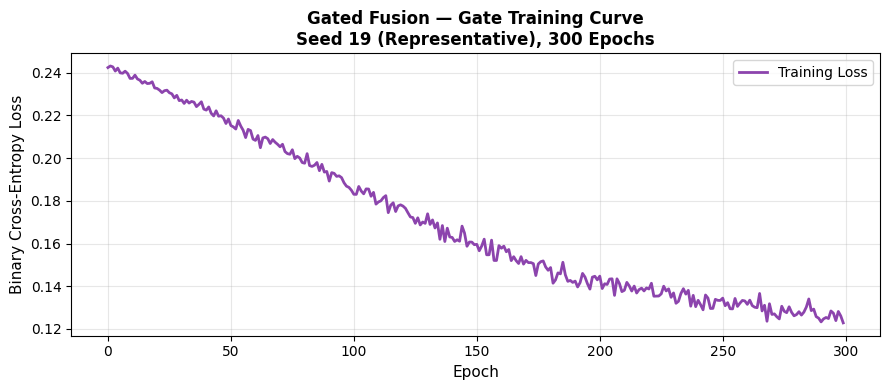

In [ ]:
# Gate Training Curve
tf.random.set_seed(N_SEEDS - 1)
np.random.seed(N_SEEDS - 1)

px_val_last, pc_val_last, y_val_last = create_fusion_pairs(
    p_xray_val, y_xray_val, p_cough_val, y_cough_val, seed=N_SEEDS - 1)

X_gate_last  = build_gate_features(px_val_last, pc_val_last)
px_f = px_val_last.astype(np.float32)
pc_f = pc_val_last.astype(np.float32)
y_f  = y_val_last.astype(np.float32)

gate_curve    = build_gate_model(input_dim=7)
optimizer_crv = keras.optimizers.Adam(1e-3)
train_losses_curve = []

CURVE_EPOCHS = 300
for ep in range(CURVE_EPOCHS):
    with tf.GradientTape() as tape:
        g_c     = gate_curve(X_gate_last, training=True)[:, 0]
        p_c     = tf.clip_by_value(g_c * px_f + (1 - g_c) * pc_f, 1e-7, 1 - 1e-7)
        loss_c  = tf.reduce_mean(keras.losses.binary_crossentropy(y_f, p_c))
    grads = tape.gradient(loss_c, gate_curve.trainable_variables)
    optimizer_crv.apply_gradients(zip(grads, gate_curve.trainable_variables))
    train_losses_curve.append(loss_c.numpy())

plt.figure(figsize=(9, 4))
plt.plot(train_losses_curve, color='#8c44ad', linewidth=2, label='Training Loss')
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Binary Cross-Entropy Loss", fontsize=11)
plt.title(f"Gated Fusion — Gate Training Curve\n"
          f"Seed {N_SEEDS - 1} (Representative), {CURVE_EPOCHS} Epochs",
          fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Confusion Matrices — Late Fusion & Gated Fusion
def plot_confusion_matrix(ax, y_true, y_pred, title, cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred)
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(CLASS_NAMES); ax.set_yticklabels(CLASS_NAMES)
    thresh_val = cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm[i, j] > thresh_val else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def averaged_confusion_matrix(all_y_true, all_y_pred):
    """
    Compute confusion matrix from per-seed averaged counts.
    Each seed contributes one CM, then we sum all CMs — this is
    the correct per-seed method: every seed is weighted equally
    regardless of small pairing count differences.
    """
    cm_sum = np.zeros((2, 2), dtype=int)
    for y_t, y_p in zip(all_y_true, all_y_pred):
        cm_sum += confusion_matrix(y_t, y_p, labels=[0, 1])
    return cm_sum


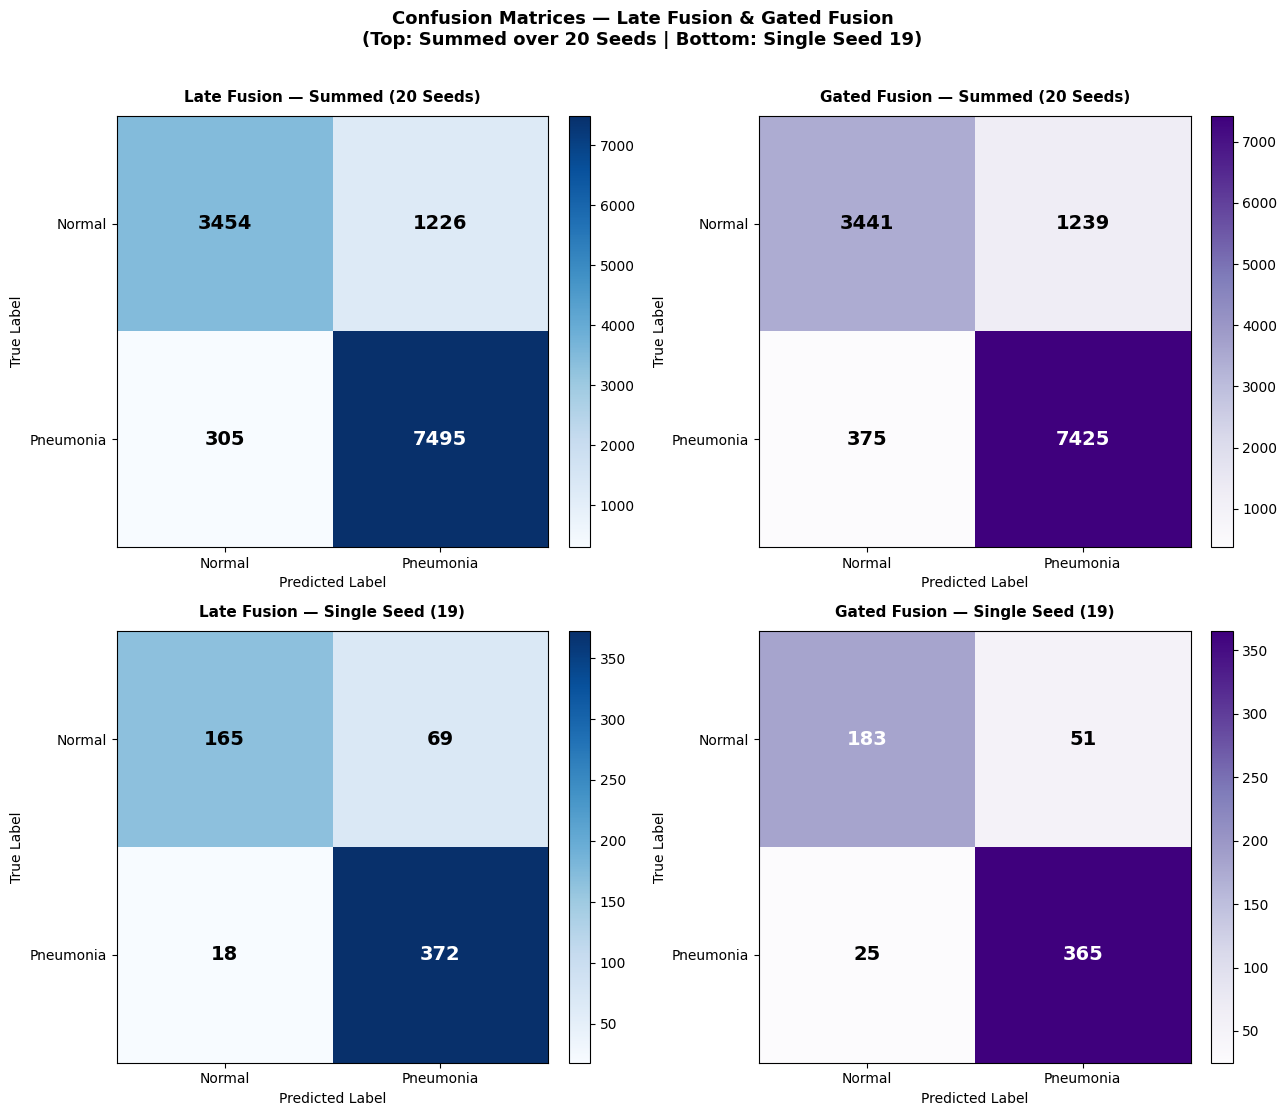

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.suptitle("Confusion Matrices — Late Fusion & Gated Fusion\n"
             f"(Top: Summed over {N_SEEDS} Seeds | Bottom: Single Seed {N_SEEDS-1})",
             fontsize=13, fontweight='bold', y=1.01)

# Summed across all seeds (per-seed consistent)
plot_confusion_matrix(
    axes[0, 0],
    np.concatenate(late_all_y_true),
    np.concatenate(late_all_y_pred),
    f"Late Fusion — Summed ({N_SEEDS} Seeds)",
    cmap='Blues')

plot_confusion_matrix(
    axes[0, 1],
    np.concatenate(gated_all_y_true),
    np.concatenate(gated_all_y_pred),
    f"Gated Fusion — Summed ({N_SEEDS} Seeds)",
    cmap='Purples')

# Single representative seed
plot_confusion_matrix(
    axes[1, 0],
    late_last['y_true'], late_last['y_pred'],
    f"Late Fusion — Single Seed ({N_SEEDS-1})",
    cmap='Blues')

plot_confusion_matrix(
    axes[1, 1],
    gated_last['y_true'], gated_last['y_pred'],
    f"Gated Fusion — Single Seed ({N_SEEDS-1})",
    cmap='Purples')

plt.tight_layout()
plt.show()

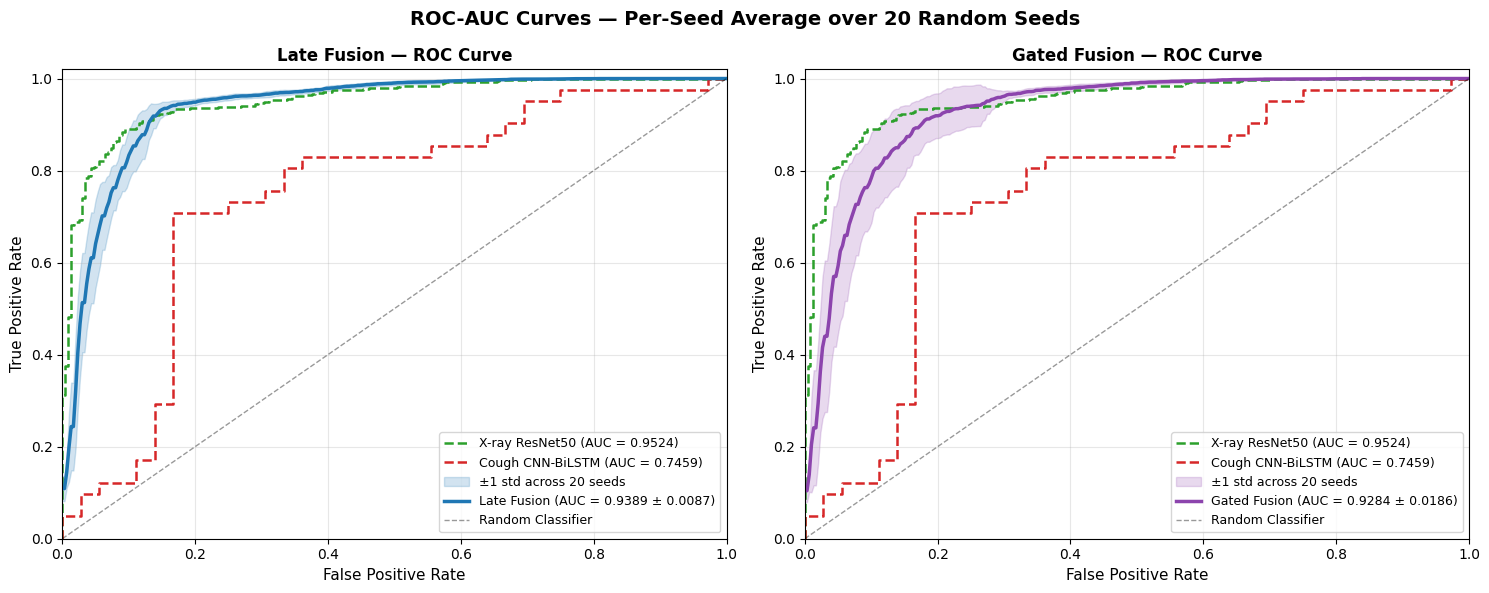

In [ ]:
#ROC-AUC CURVES
def average_roc(fpr_list, tpr_list):
    """
    Interpolate each seed's ROC to a common FPR grid,
    then compute mean and std across seeds.
    This is the correct per-seed average for ROC curves.
    """
    base_fpr    = np.linspace(0, 1, 300)
    tprs_interp = [np.interp(base_fpr, fpr, tpr)
                   for fpr, tpr in zip(fpr_list, tpr_list)]
    mean_tpr = np.mean(tprs_interp, axis=0)
    std_tpr  = np.std(tprs_interp,  axis=0)
    return base_fpr, mean_tpr, std_tpr

# Unimodal ROC on full original test sets (reference lines)
fpr_xray_full,  tpr_xray_full,  _ = roc_curve(y_xray_test,  p_xray_test)
fpr_cough_full, tpr_cough_full, _ = roc_curve(y_cough_test, p_cough_test)
auc_xray_full  = roc_auc_score(y_xray_test,  p_xray_test)
auc_cough_full = roc_auc_score(y_cough_test, p_cough_test)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f"ROC-AUC Curves — Per-Seed Average over {N_SEEDS} Random Seeds",
             fontsize=14, fontweight='bold')

for ax, fpr_list, tpr_list, agg, fusion_label, color, title in [
    (axes[0],
     late_fpr_list,  late_tpr_list,  late_agg,
     "Late Fusion",  "#1f77b4",
     "Late Fusion — ROC Curve"),
    (axes[1],
     gated_fpr_list, gated_tpr_list, gated_agg,
     "Gated Fusion", "#8c44ad",
     "Gated Fusion — ROC Curve"),
]:
    base_fpr, mean_tpr, std_tpr = average_roc(fpr_list, tpr_list)
    mean_auc = agg['auc'][0]
    std_auc  = agg['auc'][1]

    # Unimodal reference dashed lines
    ax.plot(fpr_xray_full, tpr_xray_full,
            color='#2ca02c', lw=1.8, linestyle='--',
            label=f"X-ray ResNet50 (AUC = {auc_xray_full:.4f})")
    ax.plot(fpr_cough_full, tpr_cough_full,
            color='#d62728', lw=1.8, linestyle='--',
            label=f"Cough CNN-BiLSTM (AUC = {auc_cough_full:.4f})")

    # Fusion mean ROC + ±1 std shaded band
    ax.fill_between(base_fpr,
                    np.clip(mean_tpr - std_tpr, 0, 1),
                    np.clip(mean_tpr + std_tpr, 0, 1),
                    alpha=0.2, color=color,
                    label=f"±1 std across {N_SEEDS} seeds")
    ax.plot(base_fpr, mean_tpr, color=color, lw=2.5,
            label=f"{fusion_label} (AUC = {mean_auc:.4f} ± {std_auc:.4f})")

    # Random classifier diagonal
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4,
            label='Random Classifier')

    ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

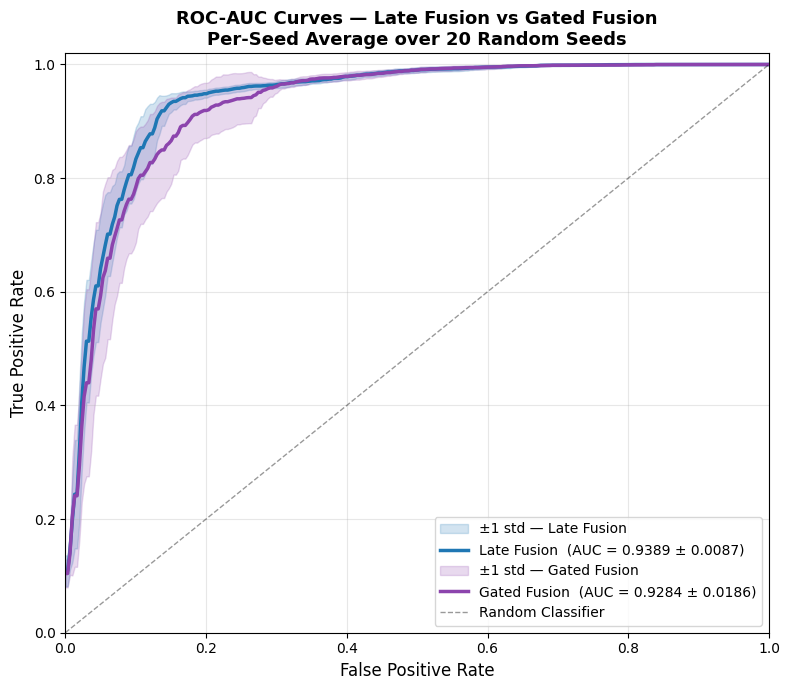

In [ ]:
# ROC-AUC CURVE — Late Fusion and Gated Fusion

fig, ax = plt.subplots(figsize=(8, 7))

for fpr_list, tpr_list, agg, fusion_label, color in [
    (late_fpr_list,  late_tpr_list,  late_agg,
     "Late Fusion",  "#1f77b4"),
    (gated_fpr_list, gated_tpr_list, gated_agg,
     "Gated Fusion", "#8c44ad"),
]:
    base_fpr, mean_tpr, std_tpr = average_roc(fpr_list, tpr_list)
    mean_auc = agg['auc'][0]
    std_auc  = agg['auc'][1]

    # ±1 std shaded band
    ax.fill_between(base_fpr,
                    np.clip(mean_tpr - std_tpr, 0, 1),
                    np.clip(mean_tpr + std_tpr, 0, 1),
                    alpha=0.2, color=color,
                    label=f"±1 std — {fusion_label}")

    # Mean ROC curve
    ax.plot(base_fpr, mean_tpr, color=color, lw=2.5,
            label=f"{fusion_label}  (AUC = {mean_auc:.4f} ± {std_auc:.4f})")

# Random classifier diagonal
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4,
        label='Random Classifier')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f"ROC-AUC Curves — Late Fusion vs Gated Fusion\n"
             f"Per-Seed Average over {N_SEEDS} Random Seeds",
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

###QUANTIFY PERFORMANCE GAIN

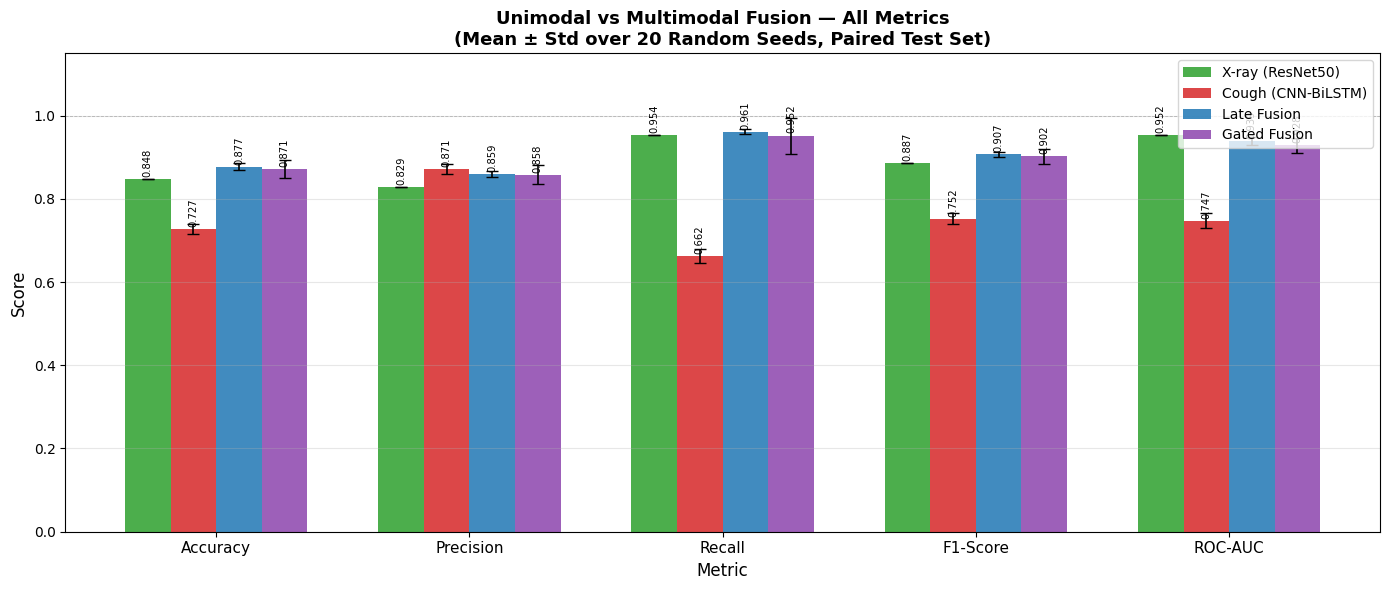

In [ ]:
#Grouped Bar Chart — All metrics, all models
metric_keys  = ['accuracy', 'precision', 'recall', 'f1', 'auc']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

xray_means  = [xray_agg[k][0]  for k in metric_keys]
xray_stds   = [xray_agg[k][1]  for k in metric_keys]
cough_means = [cough_agg[k][0] for k in metric_keys]
cough_stds  = [cough_agg[k][1] for k in metric_keys]
late_means  = [late_agg[k][0]  for k in metric_keys]
late_stds   = [late_agg[k][1]  for k in metric_keys]
gated_means = [gated_agg[k][0] for k in metric_keys]
gated_stds  = [gated_agg[k][1] for k in metric_keys]

x     = np.arange(len(metric_names))
width = 0.18

fig, ax = plt.subplots(figsize=(14, 6))

b1 = ax.bar(x - 1.5*width, xray_means,  width, yerr=xray_stds,
            label='X-ray (ResNet50)',    color='#2ca02c', alpha=0.85,
            capsize=4, error_kw={'linewidth': 1.2})
b2 = ax.bar(x - 0.5*width, cough_means, width, yerr=cough_stds,
            label='Cough (CNN-BiLSTM)', color='#d62728', alpha=0.85,
            capsize=4, error_kw={'linewidth': 1.2})
b3 = ax.bar(x + 0.5*width, late_means,  width, yerr=late_stds,
            label='Late Fusion',        color='#1f77b4', alpha=0.85,
            capsize=4, error_kw={'linewidth': 1.2})
b4 = ax.bar(x + 1.5*width, gated_means, width, yerr=gated_stds,
            label='Gated Fusion',       color='#8c44ad', alpha=0.85,
            capsize=4, error_kw={'linewidth': 1.2})

# Value labels on top of each bar
for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2.,
                h + 0.005, f"{h:.3f}",
                ha='center', va='bottom', fontsize=7.2, rotation=90)

ax.set_ylim(0.0, 1.15)
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Unimodal vs Multimodal Fusion — All Metrics\n'
             f'(Mean ± Std over {N_SEEDS} Random Seeds, Paired Test Set)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metric_names, fontsize=11)
ax.legend(fontsize=10, loc='upper right')
ax.axhline(1.0, color='gray', linewidth=0.6, linestyle='--', alpha=0.5)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

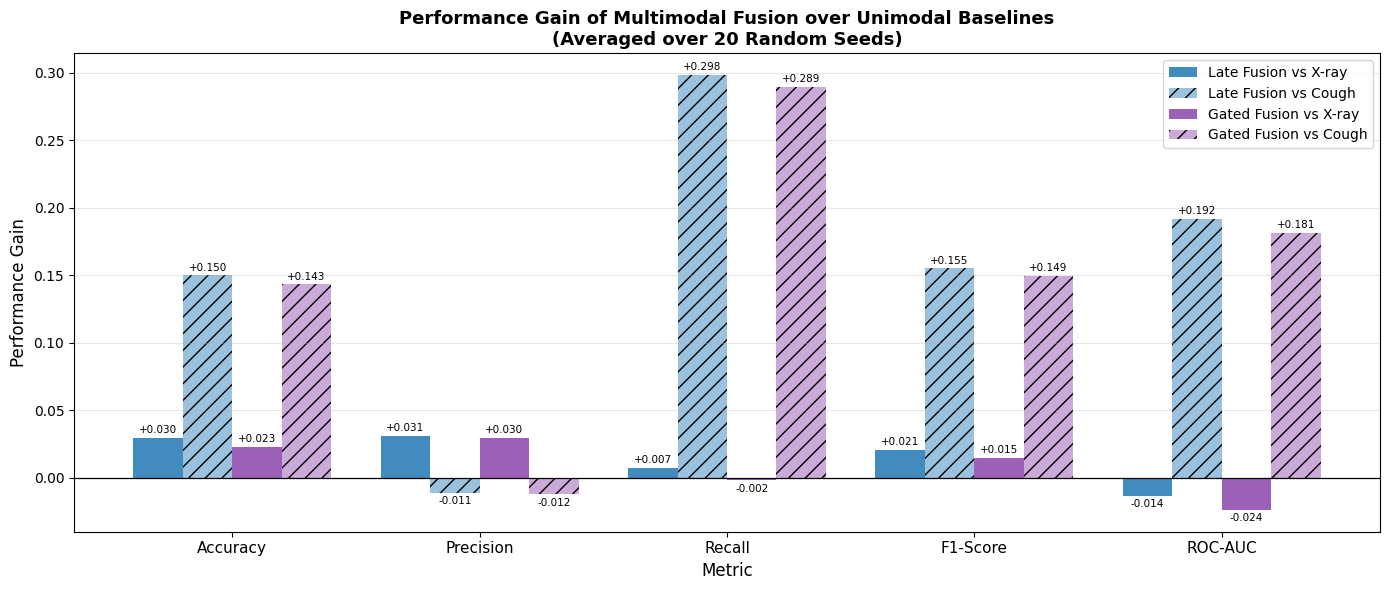

In [ ]:
# ── Plot 2: Performance Gain Bar Chart ───────────────────────
late_vs_xray  = [late_agg[k][0]  - xray_agg[k][0]  for k in metric_keys]
late_vs_cough = [late_agg[k][0]  - cough_agg[k][0] for k in metric_keys]
gate_vs_xray  = [gated_agg[k][0] - xray_agg[k][0]  for k in metric_keys]
gate_vs_cough = [gated_agg[k][0] - cough_agg[k][0] for k in metric_keys]

x     = np.arange(len(metric_names))
width = 0.20

fig, ax = plt.subplots(figsize=(14, 6))

b1 = ax.bar(x - 1.5*width, late_vs_xray,  width,
            label='Late Fusion vs X-ray',   color='#1f77b4', alpha=0.85)
b2 = ax.bar(x - 0.5*width, late_vs_cough, width,
            label='Late Fusion vs Cough',   color='#1f77b4', alpha=0.45, hatch='//')
b3 = ax.bar(x + 0.5*width, gate_vs_xray,  width,
            label='Gated Fusion vs X-ray',  color='#8c44ad', alpha=0.85)
b4 = ax.bar(x + 1.5*width, gate_vs_cough, width,
            label='Gated Fusion vs Cough',  color='#8c44ad', alpha=0.45, hatch='//')

ax.axhline(0, color='black', linewidth=0.9)

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2.,
                h + (0.002 if h >= 0 else -0.010),
                f"{h:+.3f}", ha='center', va='bottom', fontsize=7.5)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Performance Gain', fontsize=12)
ax.set_title('Performance Gain of Multimodal Fusion over Unimodal Baselines\n'
             f'(Averaged over {N_SEEDS} Random Seeds)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metric_names, fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

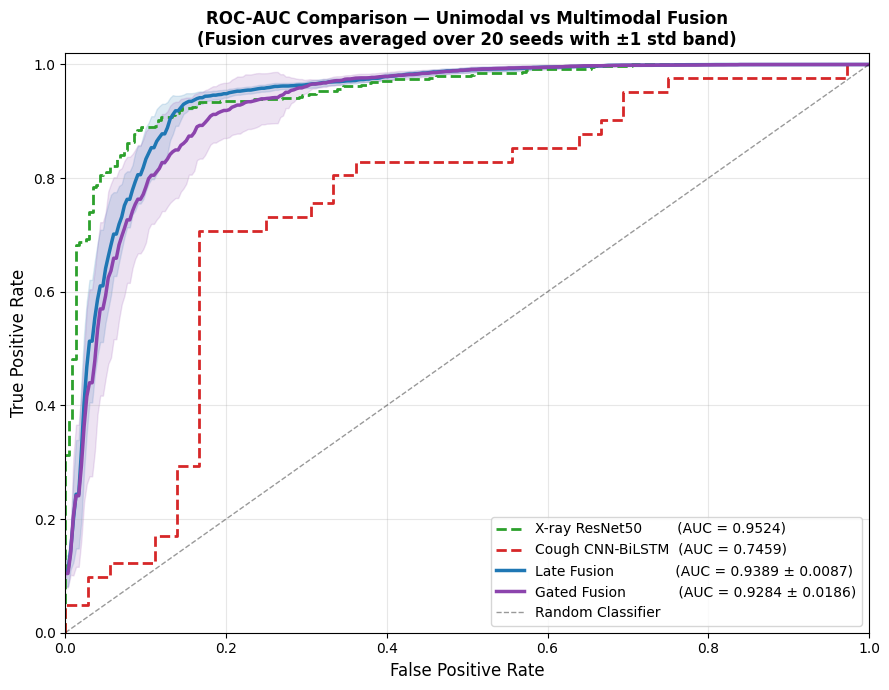

In [ ]:
# AUC-focused comparison — all 4 models on one ROC ─
fig, ax = plt.subplots(figsize=(9, 7))

# X-ray and Cough on full original test sets
ax.plot(fpr_xray_full, tpr_xray_full,
        color='#2ca02c', lw=2, linestyle='--',
        label=f"X-ray ResNet50        (AUC = {auc_xray_full:.4f})")
ax.plot(fpr_cough_full, tpr_cough_full,
        color='#d62728', lw=2, linestyle='--',
        label=f"Cough CNN-BiLSTM  (AUC = {auc_cough_full:.4f})")

# Late Fusion averaged ROC
base_fpr_l, mean_tpr_l, std_tpr_l = average_roc(late_fpr_list, late_tpr_list)
ax.fill_between(base_fpr_l,
                np.clip(mean_tpr_l - std_tpr_l, 0, 1),
                np.clip(mean_tpr_l + std_tpr_l, 0, 1),
                alpha=0.15, color='#1f77b4')
ax.plot(base_fpr_l, mean_tpr_l, color='#1f77b4', lw=2.5,
        label=f"Late Fusion              (AUC = {late_agg['auc'][0]:.4f} ± {late_agg['auc'][1]:.4f})")

# Gated Fusion averaged ROC
base_fpr_g, mean_tpr_g, std_tpr_g = average_roc(gated_fpr_list, gated_tpr_list)
ax.fill_between(base_fpr_g,
                np.clip(mean_tpr_g - std_tpr_g, 0, 1),
                np.clip(mean_tpr_g + std_tpr_g, 0, 1),
                alpha=0.15, color='#8c44ad')
ax.plot(base_fpr_g, mean_tpr_g, color='#8c44ad', lw=2.5,
        label=f"Gated Fusion            (AUC = {gated_agg['auc'][0]:.4f} ± {gated_agg['auc'][1]:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Random Classifier')
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-AUC Comparison — Unimodal vs Multimodal Fusion\n'
             f'(Fusion curves averaged over {N_SEEDS} seeds with ±1 std band)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CLASSIFICATION REPORTS — ALL FOUR MODELS
# Paired Test Set | Per-Seed Average
# ============================================================

from sklearn.metrics import precision_recall_fscore_support

# ── Per-seed report storage for X-ray and Cough unimodal ────
xray_per_seed_report = {
    'normal_prec': [], 'normal_rec': [], 'normal_f1': [],
    'pneumonia_prec': [], 'pneumonia_rec': [], 'pneumonia_f1': [],
    'normal_support': [], 'pneumonia_support': []
}
cough_per_seed_report = {
    'normal_prec': [], 'normal_rec': [], 'normal_f1': [],
    'pneumonia_prec': [], 'pneumonia_rec': [], 'pneumonia_f1': [],
    'normal_support': [], 'pneumonia_support': []
}

# Collect per-seed unimodal per-class metrics from the
# already-computed paired test sets used in the fusion loops.
# We re-run the pairing here to extract per-class metrics cleanly.
for s in range(N_SEEDS):
    px_t, pc_t, y_t = create_fusion_pairs(
        p_xray_test, y_xray_test,
        p_cough_test, y_cough_test, seed=s)

    # X-ray unimodal predictions on paired subset
    xray_pred  = (px_t >= XRAY_THRESHOLD).astype(int)
    cough_pred = (pc_t >= COUGH_THRESHOLD).astype(int)

    prec_x, rec_x, f1_x, sup_x = precision_recall_fscore_support(
        y_t, xray_pred, labels=[0, 1], zero_division=0)
    prec_c, rec_c, f1_c, sup_c = precision_recall_fscore_support(
        y_t, cough_pred, labels=[0, 1], zero_division=0)

    xray_per_seed_report['normal_prec'].append(prec_x[0])
    xray_per_seed_report['normal_rec'].append(rec_x[0])
    xray_per_seed_report['normal_f1'].append(f1_x[0])
    xray_per_seed_report['pneumonia_prec'].append(prec_x[1])
    xray_per_seed_report['pneumonia_rec'].append(rec_x[1])
    xray_per_seed_report['pneumonia_f1'].append(f1_x[1])
    xray_per_seed_report['normal_support'].append(sup_x[0])
    xray_per_seed_report['pneumonia_support'].append(sup_x[1])

    cough_per_seed_report['normal_prec'].append(prec_c[0])
    cough_per_seed_report['normal_rec'].append(rec_c[0])
    cough_per_seed_report['normal_f1'].append(f1_c[0])
    cough_per_seed_report['pneumonia_prec'].append(prec_c[1])
    cough_per_seed_report['pneumonia_rec'].append(rec_c[1])
    cough_per_seed_report['pneumonia_f1'].append(f1_c[1])
    cough_per_seed_report['normal_support'].append(sup_c[0])
    cough_per_seed_report['pneumonia_support'].append(sup_c[1])


# ── Report printer — mean only, no std ───────────────────────
def print_report(report_dict, acc_list, title, threshold_info=""):
    """
    Prints classification report using per-seed averaged values.
    Shows mean only — no ± std.
    """
    n_prec = np.mean(report_dict['normal_prec'])
    n_rec  = np.mean(report_dict['normal_rec'])
    n_f1   = np.mean(report_dict['normal_f1'])
    p_prec = np.mean(report_dict['pneumonia_prec'])
    p_rec  = np.mean(report_dict['pneumonia_rec'])
    p_f1   = np.mean(report_dict['pneumonia_f1'])
    n_sup  = np.mean(report_dict['normal_support'])
    p_sup  = np.mean(report_dict['pneumonia_support'])

    total_sup   = n_sup + p_sup
    accuracy    = np.mean(acc_list)
    macro_prec  = (n_prec + p_prec) / 2
    macro_rec   = (n_rec  + p_rec)  / 2
    macro_f1    = (n_f1   + p_f1)   / 2
    w_prec      = (n_prec * n_sup + p_prec * p_sup) / total_sup
    w_rec       = (n_rec  * n_sup + p_rec  * p_sup) / total_sup
    w_f1        = (n_f1   * n_sup + p_f1   * p_sup) / total_sup

    w = 62
    print("\n" + "=" * w)
    print(f"  CLASSIFICATION REPORT — {title}")
    print(f"  Paired Test Set | Per-Seed Average over {N_SEEDS} Seeds")
    if threshold_info:
        print(f"  {threshold_info}")
    print("=" * w)
    print(f"{'':>15} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>9}")
    print("-" * w)
    print(f"{'Normal':>15} {n_prec:>10.4f} {n_rec:>10.4f} {n_f1:>10.4f} {n_sup:>9.0f}")
    print(f"{'Pneumonia':>15} {p_prec:>10.4f} {p_rec:>10.4f} {p_f1:>10.4f} {p_sup:>9.0f}")
    print("-" * w)
    print(f"{'accuracy':>15} {'':>10} {'':>10} {accuracy:>10.4f} {total_sup:>9.0f}")
    print(f"{'macro avg':>15} {macro_prec:>10.4f} {macro_rec:>10.4f} {macro_f1:>10.4f} {total_sup:>9.0f}")
    print(f"{'weighted avg':>15} {w_prec:>10.4f} {w_rec:>10.4f} {w_f1:>10.4f} {total_sup:>9.0f}")
    print("=" * w)


# ── Print all four reports ────────────────────────────────────
print_report(
    xray_per_seed_report,
    xray_metrics['accuracy'],
    "X-RAY UNIMODAL — ResNet50",
    f"Threshold = {XRAY_THRESHOLD}"
)

print_report(
    cough_per_seed_report,
    cough_metrics['accuracy'],
    "COUGH UNIMODAL — CNN-BiLSTM",
    f"Threshold = {COUGH_THRESHOLD}"
)

print_report(
    late_per_seed_report,
    late_metrics['accuracy'],
    "LATE FUSION — Weighted Averaging",
    f"Threshold = {LATE_THRESHOLD:.4f}  |  w_xray = {best_w:.2f}  |  w_cough = {1 - best_w:.2f}"
)

print_report(
    gated_per_seed_report,
    gated_metrics['accuracy'],
    "GATED FUSION",
    f"Mean Threshold = {np.mean(gated_thresh_list):.4f}"
)


  CLASSIFICATION REPORT — X-RAY UNIMODAL — ResNet50
  Paired Test Set | Per-Seed Average over 20 Seeds
  Threshold = 0.6677
                 precision     recall   f1-score   support
--------------------------------------------------------------
         Normal     0.8971     0.6709     0.7677       234
      Pneumonia     0.8285     0.9538     0.8868       390
--------------------------------------------------------------
       accuracy                           0.8478       624
      macro avg     0.8628     0.8124     0.8272       624
   weighted avg     0.8542     0.8478     0.8421       624

  CLASSIFICATION REPORT — COUGH UNIMODAL — CNN-BiLSTM
  Paired Test Set | Per-Seed Average over 20 Seeds
  Threshold = 0.4295
                 precision     recall   f1-score   support
--------------------------------------------------------------
         Normal     0.5978     0.8357     0.6969       234
      Pneumonia     0.8706     0.6624     0.7522       390
----------------------------